### Imports

In [31]:
import numpy as np
import yfinance as yf
from datetime import datetime
from matplotlib import pyplot as plt
import pandas as pd
from deap import base, creator, tools, algorithms
from sklearn.metrics import auc
import os
import time
import pickle
from itertools import repeat
try:
    from collections.abc import Sequence
except ImportError:
    from collections import Sequence

# np.random.seed(123)
np.set_printoptions(suppress=True)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

### Data

In [32]:
# LEVEL 1
stock_tickers = '''AAPL MSFT GOOGL JNJ V WMT XOM HD BAC PFE CSCO NKE COST MCD QCOM UNH UPS SBUX CAT WM'''


In [33]:
#LEVEL 2
stock_tickers = '''AAPL ABT ADBE AMD AMZN AXP BA BABA BAC CSCO CVS DHR DIS F GLD GOOGL
                 GS HD HON IBM INTC JNJ KO LLY LVMUY MA MCD META MMM MSFT NFLX NKE
                 NVDA ORCL PFE PG PYPL QCOM RIO RTX SAP SBUX SIEGY T TM TMO TSLA
                 UNH V WMT'''

In [34]:
# LEVEL 3
stock_tickers = '''AAPL MSFT AMZN NVDA GOOGL GOOG META UNH JNJ
                   V XOM JPM MA PG ADBE PEP CVX MRK AVGO
                   LLY KO COST TSM HD ABT NFLX CSCO VZ ABBV
                   NEE WMT NVO ORCL ACN DHR AMD PFE MCD LIN
                   MDT TMO RTX TXN BMY PM SBUX AMGN HON UPS
                   CVS IBM ISRG UNP DE SPGI MO GS COP ELV
                   LMT QCOM LOW SLB INTU GE C PGR ADP CAT
                   PLD ZTS CB TGT BKNG AXP PYPL SO USB AMT
                   SCHW MMC GILD BX MMM NOW SYK CL GM
                   CI MU MRVL NOC TJX HCA SPG NSC
                   EXC CDNS FDX MAR STT ADM AON BSX ETN
                   PANW CARR EWBC AMAT KLAC HSY AEP BLK MPC
                   WM MDLZ SHW PXD RSG ROST KDP KMB EW TWLO
                   MTD TRV ED EQIX D APTV REGN DLR ILMN CDW
                   VRTX WEC AJG SRE TT FISV MS HOLX CNC
                   AMCR EMN OKE PSX TAP XRAY
                   ZBH ALNY FANG HLN INVH OTIS WAT AEE ARE
                   AVB CTAS CTRA DG DFS ECL EQR ESS EVRG
                   FTV FOXA FOXF GL GLPI GPN HLT HSIC HST
                   K KIM LEG LEN LNC LYB MAA MPWR MRO NRG
                   NUE O OMC PPL PSA QSR SLG SMG SWK
                   TEL TROW VNO VTR WMB WPC WU WY VICI
                   BRX ESGR VREX WW YUM ZBRA'''

In [35]:
start_date = datetime(2018, 3, 1)
end_date = datetime(2024,3,1)

stock_data = yf.Tickers(stock_tickers).history(start = start_date, end = end_date)['Close']
stock_tickers = stock_tickers.split()
num_assets = len(stock_tickers)
budget = 1000000

current_prices = stock_data.iloc[-1].values
daily_returns = np.log(stock_data/stock_data.shift(1)).dropna()
daily_returns_mean = daily_returns.mean().values
daily_returns_std = daily_returns.std().values
daily_returns_var = daily_returns.var().values
daily_returns_covmat = daily_returns.cov().reset_index(drop=True).values

[*********************100%%**********************]  210 of 210 completed


## Evolutionary Algorithm

In [36]:
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)
toolbox = base.Toolbox()

### Fitness Function

In [37]:
def compute_avg_variance(individual):
    relative_amounts = individual / np.sum(individual)
    n = num_assets
    # w_std = daily_returns_std * relative_amounts
    w_var = daily_returns_var * relative_amounts
    i_indices, j_indices = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')

    cov_terms = 2 * relative_amounts[i_indices] * relative_amounts[j_indices] * daily_returns_covmat[i_indices, j_indices]

    off_diagonal_mask = 1-np.eye(n,n)
    # overall_avg_variance = np.sum((w_std[:, None] + w_std[None, :] + cov_terms) * off_diagonal_mask)
    overall_avg_variance = np.sum((w_var[:, None] + w_var[None, :] + cov_terms) * off_diagonal_mask)

    return overall_avg_variance

def evaluate(individual):
    for i in individual:
        if i < 0:
            return 10, -10
    individual = np.array(individual)
    avg_variance = compute_avg_variance(individual)
    avg_return = np.sum(individual*daily_returns_mean)

    return avg_variance, avg_return

toolbox.register("evaluate", evaluate)

### Individuals

In [38]:
# def generate_individual():
#     while True:
#         individual = np.random.randint(0,100, num_assets)
#         if np.sum(individual * current_prices) <= budget:
#             return individual.tolist()

# def generate_individual():
#     if not hasattr(generate_individual, 'call_count'):
#         generate_individual.call_count = 0

#     if generate_individual.call_count == 0:
#         individual = np.ones(num_assets)
#     # elif generate_individual.call_count > 0 and generate_individual.call_count < num_assets:
#     #     individual = np.zeros(num_assets)
#     #     individual[generate_individual.call_count - 1] = math.floor(budget / current_prices[generate_individual.call_count - 1])
#     else:
#         while True:
#             individual = np.random.randint(0,100, num_assets)
#             if np.dot(np.array(individual), current_prices) <= budget:
#                 individual = individual.tolist()
#                 break
#     generate_individual.call_count += 1
#     return individual

def generate_individual_v2():
    max_budget = budget + 1
    while max_budget > budget:
        ind = [0 for i in range(num_assets)]
        stocks_to_buy = np.random.randint(0,num_assets)
        stocks_bought = []
        current_budget = budget
        for i in range(stocks_to_buy):
            stock_to_buy = np.random.randint(0, num_assets)
            while stock_to_buy in stocks_bought:
                stock_to_buy = np.random.randint(0, num_assets)
            stocks_bought.append(stock_to_buy)
            upperbound_default = int(current_budget/current_prices[stock_to_buy])
            if upperbound_default > 1:
                ind[stock_to_buy] = np.random.randint(1,upperbound_default)
            current_budget = budget - np.dot(np.array(ind), current_prices)

        max_budget = np.dot(np.array(ind), current_prices)

    return ind

toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual_v2)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

### Selection

In [39]:
#toolbox.register("select", tools.selNSGA2)
#selection_method = 'selNSGA2'

toolbox.register("select", tools.selSPEA2)
selection_method = 'selSPEA2'

#toolbox.register("select", tools.selDoubleTournament, fitness_size=3, parsimony_size=2, fitness_first=True)
#selection_method = 'selDoubleTournament'

### Utilities

In [40]:
def check_budget_constraint(individual, delta = 1, power = 1):
    individual_np = np.array(individual, dtype=int)
    while np.dot(individual_np, current_prices) > budget:
        fix_start_time = time.time()

        possible_indices = np.where(individual_np > 0)[0]
        if len(possible_indices) == 0:
            break
        index_count = min(power, len(possible_indices))
        index = np.random.choice(possible_indices, index_count, replace=False)
        individual_np[index] -= delta

        fix_end_time = time.time()
        fix_time = fix_end_time-fix_start_time
        if fix_time > 2:
            print(f'bugdet fixing time: {fix_time}')

    for i in range(len(individual)):
        individual[i] = int(individual_np[i])
    return individual

def check_negatives(individual):
    for i in range(num_assets):
        individual[i] = int(individual[i])
        if individual[i] < 0:
            individual[i] = 0
    return individual

def eaMuPlusLambda_with_auc(population, toolbox, mu, lambda_, cxpb, mutpb, ngen, stats=None,
                            halloffame=None, verbose=__debug__):
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals', 'auc']

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats is not None else {}
    logbook.record(gen=0, nevals=len(invalid_ind), auc=0, **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):
        # Vary the population
        offspring = algorithms.varOr(population, toolbox, lambda_, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Update the hall of fame with the generated individuals
        if halloffame is not None:
            halloffame.update(offspring)

        # Select the next generation population
        population[:] = toolbox.select(population + offspring, mu)

        # Calculate and record AUC of the Pareto front
        pareto_front = tools.sortNondominated(population, len(population), first_front_only=True)[0]
        variances = [ind.fitness.values[0] for ind in pareto_front]
        returns = [ind.fitness.values[1] for ind in pareto_front]

        sorted_indices = np.argsort(variances)
        variances_sorted = np.array(variances)[sorted_indices]
        returns_sorted = np.array(returns)[sorted_indices]
        pareto_auc = auc(variances_sorted, returns_sorted)

        # Update the statistics with the new population
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), auc=pareto_auc)
        if verbose:
            print(logbook.stream)

    return population, logbook

### Crossover

In [41]:
# def fix_budget_constraint(offspring, parent, lim_attempts):
#     attempts = 0
#     while attempts < lim_attempts:
#         attempts +=1
#         index = np.random.randint(0, num_assets - 1)
#         if offspring[index] - 10 >= 0:
#             offspring[index] -= 10
#         elif offspring[index] - 1 >= 0:
#             offspring[index] -= 1
#         else:
#             attempts -= 1
#         if np.dot(np.array(offspring), current_prices) <= budget:
#             return offspring
#     print('WARNING: individual not mated.')
#     return parent

def mate(ind1, ind2):

    offspring1, offspring2 = tools.cxOnePoint(ind1, ind2)
    # offspring1, offspring2 = tools.cxBlend(ind1, ind2, alpha=0.5)
    # offspring1, offspring2 = tools.cxUniform(ind1, ind2, indpb=0.5)

    offspring1, offspring2 = check_negatives(offspring1), check_negatives(offspring2)

    delta, power = 1, 1
    offspring1 = check_budget_constraint(offspring1, delta, power)
    offspring2 = check_budget_constraint(offspring2, delta, power)

    return offspring1, offspring2

crossover_method = 'cxOnePoint'
# crossover_method = 'cxBlend'
# crossover_method = 'cxUniform'

toolbox.register('mate', mate)

### Mutation

In [42]:
def adaptive_mutUniformInt(individual, low, indpb, current_budget, push, up=1):
    """Mutate an individual by replacing attributes, with probability *indpb*,
    by a integer uniformly drawn between *low* and *up* inclusively.

    :param individual: :term:`Sequence <sequence>` individual to be mutated.
    :param low: The lower bound or a :term:`python:sequence` of
                of lower bounds of the range from which to draw the new
                integer.
    :param up: The upper bound or a :term:`python:sequence` of
               of upper bounds of the range from which to draw the new
               integer.
    :param indpb: Independent probability for each attribute to be mutated.
    :returns: A tuple of one individual.
    """
    size = len(individual)
    if not isinstance(low, Sequence):
        low = repeat(low, size)
    elif len(low) < size:
        raise IndexError("low must be at least the size of individual: %d < %d" % (len(low), size))
    if not isinstance(up, Sequence):
        up = repeat(up, size)
    elif len(up) < size:
        raise IndexError("up must be at least the size of individual: %d < %d" % (len(up), size))

    for i, xl, xu in zip(range(size), low, up):
        if np.random.random() < indpb:
            xu = int(current_budget / current_prices[i]) + push + individual[i]
            individual[i] = np.random.randint(xl, xu)

    return individual,

def adaptive_mutPolynomialBounded(individual, eta, low, indpb, current_budget, push, up=1):
    """Polynomial mutation as implemented in original NSGA-II algorithm in
    C by Deb.

    :param individual: :term:`Sequence <sequence>` individual to be mutated.
    :param eta: Crowding degree of the mutation. A high eta will produce
                a mutant resembling its parent, while a small eta will
                produce a solution much more different.
    :param low: A value or a :term:`python:sequence` of values that
                is the lower bound of the search space.
    :param up: A value or a :term:`python:sequence` of values that
               is the upper bound of the search space.
    :returns: A tuple of one individual.
    """
    size = len(individual)
    if not isinstance(low, Sequence):
        low = repeat(low, size)
    elif len(low) < size:
        raise IndexError("low must be at least the size of individual: %d < %d" % (len(low), size))
    if not isinstance(up, Sequence):
        up = repeat(up, size)
    elif len(up) < size:
        raise IndexError("up must be at least the size of individual: %d < %d" % (len(up), size))

    for i, xl, xu in zip(range(size), low, up):
        if np.random.random() <= indpb:
            xu = int(current_budget / current_prices[i]) + push + individual[i]
            x = individual[i]
            delta_1 = (x - xl) / (xu - xl)
            delta_2 = (xu - x) / (xu - xl)
            rand = np.random.random()
            mut_pow = 1.0 / (eta + 1.)

            if rand < 0.5:
                xy = 1.0 - delta_1
                val = 2.0 * rand + (1.0 - 2.0 * rand) * xy ** (eta + 1)
                delta_q = val ** mut_pow - 1.0
            else:
                xy = 1.0 - delta_2
                val = 2.0 * (1.0 - rand) + 2.0 * (rand - 0.5) * xy ** (eta + 1)
                delta_q = 1.0 - val ** mut_pow

            x = x + delta_q * (xu - xl)
            x = min(max(x, xl), xu)
            individual[i] = int(x)
    return individual,

def adaptive_mutGaussian(individual, mu, indpb, current_budget, push, sigma=1):
    """This function applies a gaussian mutation of mean *mu* and standard
    deviation *sigma* on the input individual. This mutation expects a
    :term:`sequence` individual composed of real valued attributes.
    The *indpb* argument is the probability of each attribute to be mutated.

    :param individual: Individual to be mutated.
    :param mu: Mean or :term:`python:sequence` of means for the
               gaussian addition mutation.
    :param sigma: Standard deviation or :term:`python:sequence` of
                  standard deviations for the gaussian addition mutation.
    :param indpb: Independent probability for each attribute to be mutated.
    :returns: A tuple of one individual.

    This function uses the :func:`~random.random` and :func:`~random.gauss`
    functions from the python base :mod:`random` module.
    """
    size = len(individual)
    if not isinstance(mu, Sequence):
        mu = repeat(mu, size)
    elif len(mu) < size:
        raise IndexError("mu must be at least the size of individual: %d < %d" % (len(mu), size))
    if not isinstance(sigma, Sequence):
        sigma = repeat(sigma, size)
    elif len(sigma) < size:
        raise IndexError("sigma must be at least the size of individual: %d < %d" % (len(sigma), size))

    for i, m, s in zip(range(size), mu, sigma):
        if np.random.random() < indpb:
            s = int(current_budget / current_prices[i]) + push
            individual[i] += np.random.normal(m, s)

    return individual,

In [43]:
def mutate(individual):

    current_budget = budget - np.dot(np.array(individual), current_prices)

    # tools.mutGaussian(individual, mu=0, sigma=1, indpb=0.1)
    # tools.mutPolynomialBounded(individual, eta=11, low=-5, up=20, indpb=0.1)
    # tools.mutUniformInt(individual, low=0, up=20, indpb=0.1)

    #adaptive_mutGaussian(individual, mu=0, indpb=0.1, current_budget=current_budget, push=2)
    adaptive_mutUniformInt(individual, low=0, indpb=0.1, current_budget=current_budget, push = 10)
    # adaptive_mutPolynomialBounded(individual, eta=11, low=0, indpb=0.1, current_budget=current_budget, push = 2)

    individual = check_negatives(individual)
    delta, power = 1, 1
    individual = check_budget_constraint(individual, delta, power)

    return individual,

#mutation_method = 'adaptive_mutGaussian'
# mutation_method = 'adaptive_mutPolynomialBounded'
mutation_method = 'adaptive_mutUniformInt'

toolbox.register("mutate", mutate)

### Excel logger

In [44]:
def log_results_to_excel(params, results, filename="optimization_log.xlsx"):

    record = {**params, **results}
    record['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    record_df = pd.DataFrame([record])

    if os.path.exists(filename):

        with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
            existing_df = pd.read_excel(filename)
            updated_df = pd.concat([existing_df, record_df], ignore_index=True)
            updated_df.to_excel(writer, index=False, sheet_name='Optimization Log')
    else:
        record_df.to_excel(filename, index=False, sheet_name='Optimization Log')


def log_results_to_csv(params, results, filename="optimization_log.csv"):
    record = {**params, **results}

    record['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    record_df = pd.DataFrame([record])

    if os.path.exists(filename):
        with open(filename, 'a') as f:
            record_df.to_csv(f, header=False, index=False)
    else:
        record_df.to_csv(filename, index=False)

### Optimisation

In [45]:
population_size = 100
CXPB, MTPB = 0.5, 0.5
NGENS = 50
epochs = 10

Initialising optimisation for 10 epochs with design:

    -   Selection: selSPEA2
    -   Crossover: cxUniform
    -   Mutation: adaptive_mutUniformInt

      
Epoch number: 1
gen	nevals	auc
0  	100   	0  
1  	100   	33.6294
2  	100   	34.1286
3  	100   	24.0497
4  	100   	24.9966
5  	100   	32.2422
6  	100   	30.381 
7  	100   	30.4682
8  	100   	30.4168
9  	100   	30.5941
10 	100   	30.7693
11 	100   	30.8511
12 	100   	31.0976
13 	100   	31.2029
14 	100   	31.0969
15 	100   	31.1379
16 	100   	31.1788
17 	100   	31.1837
18 	100   	31.2382
19 	100   	31.2344
20 	100   	31.2506
21 	100   	31.2831
22 	100   	31.2775
23 	100   	31.2811
24 	100   	31.2888
25 	100   	31.2682
26 	100   	31.4375
27 	100   	31.4393
28 	100   	31.4469
29 	100   	31.4646
30 	100   	31.4803
31 	100   	31.4789
32 	100   	31.4835
33 	100   	31.4965
34 	100   	31.4898
35 	100   	31.4878
36 	100   	31.4893
37 	100   	31.4889
38 	100   	31.47  
39 	100   	31.4871
40 	100   	31.5173
41 	100   	31.5587
42 	100   	31.5

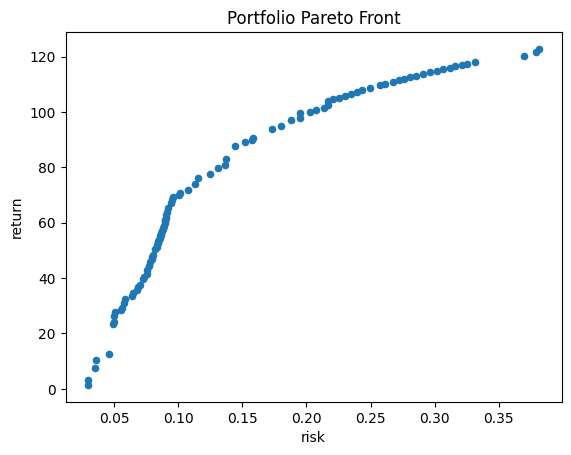

AUC: 31.62441392026325
Epoch number: 2
gen	nevals	auc
0  	100   	0  
1  	100   	18.7619
2  	100   	15.8566
3  	100   	15.8344
4  	100   	14.3548
5  	100   	14.1734
6  	100   	14.1832
7  	100   	14.7304
8  	100   	18.0441
9  	100   	19.2035
10 	100   	16.5185
11 	100   	19.2013
12 	100   	19.5917
13 	100   	20.2992
14 	100   	18.5173
15 	100   	18.5556
16 	100   	18.4183
17 	100   	18.4094
18 	100   	18.8375
19 	100   	14.1182
20 	100   	14.5905
21 	100   	14.6364
22 	100   	14.6063
23 	100   	15.0294
24 	100   	15.1109
25 	100   	15.1972
26 	100   	15.5273
27 	100   	15.5661
28 	100   	15.6286
29 	100   	16.1057
30 	100   	16.7234
31 	100   	16.7322
32 	100   	16.5385
33 	100   	16.5042
34 	100   	16.5579
35 	100   	16.5929
36 	100   	16.5961
37 	100   	15.4758
38 	100   	15.4834
39 	100   	16.0934
40 	100   	16.0631
41 	100   	16.0606
42 	100   	16.061 
43 	100   	15.8308
44 	100   	15.815 
45 	100   	16.2373
46 	100   	16.2379
47 	100   	16.3807
48 	100   	16.3411
49 	100   	16.5085


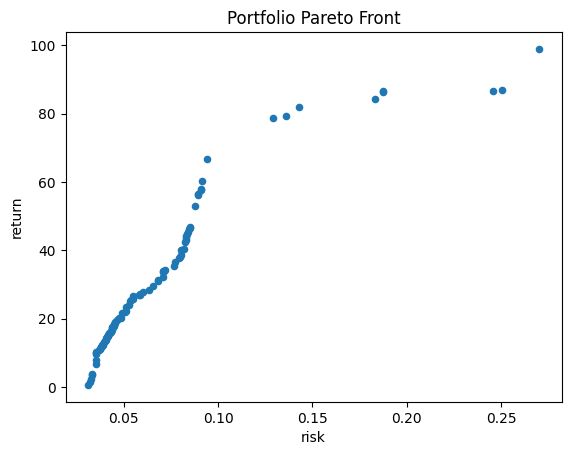

AUC: 16.500501378178544
Epoch number: 3
gen	nevals	auc
0  	100   	0  
1  	100   	1.71911
2  	100   	1.88554
3  	100   	2.55389
4  	100   	2.86258
5  	100   	5.99247
6  	100   	6.1148 
7  	100   	7.06238
8  	100   	7.08779
9  	100   	6.58801
10 	100   	6.45269
11 	100   	6.45437
12 	100   	6.4492 
13 	100   	6.44323
14 	100   	6.50062
15 	100   	6.54432
16 	100   	6.56621
17 	100   	6.56773
18 	100   	6.55887
19 	100   	6.59063
20 	100   	6.59376
21 	100   	6.59109
22 	100   	6.59996
23 	100   	6.62529
24 	100   	6.62609
25 	100   	6.62664
26 	100   	6.62812
27 	100   	6.62709
28 	100   	6.63701
29 	100   	6.64568
30 	100   	6.64344
31 	100   	6.64608
32 	100   	6.65773
33 	100   	6.66376
34 	100   	6.66465
35 	100   	6.66211
36 	100   	6.66356
37 	100   	6.71821
38 	100   	6.71843
39 	100   	6.71856
40 	100   	6.72117
41 	100   	6.73074
42 	100   	6.72897
43 	100   	6.74308
44 	100   	6.74215
45 	100   	6.74197
46 	100   	6.74556
47 	100   	6.74529
48 	100   	6.74707
49 	100   	6.75221

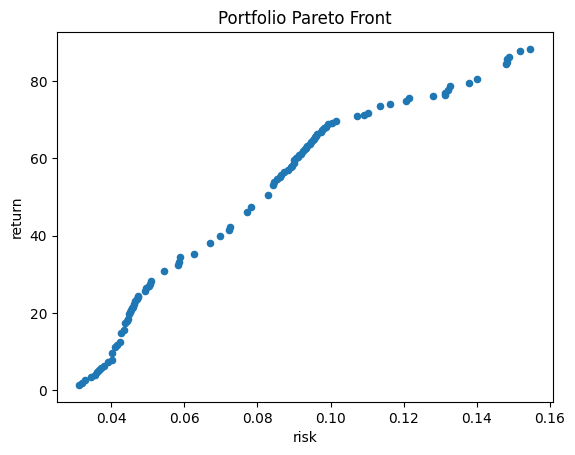

AUC: 6.757787027324303
Epoch number: 4
gen	nevals	auc
0  	100   	0  
1  	100   	2.03207
2  	100   	2.03183
3  	100   	3.16621
4  	100   	3.3963 
5  	100   	2.48406
6  	100   	3.13402
7  	100   	3.14399
8  	100   	3.1384 
9  	100   	3.11854
10 	100   	3.11227
11 	100   	3.12159
12 	100   	3.15989
13 	100   	3.17651
14 	100   	3.16523
15 	100   	3.16787
16 	100   	3.18166
17 	100   	3.18928
18 	100   	3.19918
19 	100   	3.20079
20 	100   	3.19956
21 	100   	3.19919
22 	100   	3.20743
23 	100   	3.21072
24 	100   	3.22541
25 	100   	3.22553
26 	100   	3.22645
27 	100   	3.22667
28 	100   	3.22655
29 	100   	3.22887
30 	100   	3.23154
31 	100   	3.23448
32 	100   	3.23331
33 	100   	3.23541
34 	100   	3.23632
35 	100   	3.23621
36 	100   	3.23805
37 	100   	3.23592
38 	100   	3.23598
39 	100   	3.23767
40 	100   	3.24012
41 	100   	3.2406 
42 	100   	3.24096
43 	100   	23.8196
44 	100   	29.1544
45 	100   	30.2061
46 	100   	32.4258
47 	100   	32.4224
48 	100   	17.3413
49 	100   	17.3405


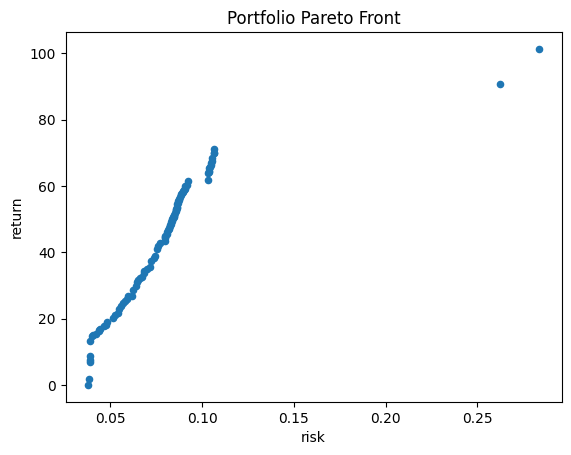

AUC: 17.341280155247873
Epoch number: 5
gen	nevals	auc
0  	100   	0  
1  	100   	1.91357
2  	100   	1.94094
3  	100   	2.18733
4  	100   	17.8528
5  	100   	18.0287
6  	100   	19.1151
7  	100   	19.2746
8  	100   	19.3277
9  	100   	19.3294
10 	100   	15.3443
11 	100   	15.3255
12 	100   	14.9957
13 	100   	15.1118
14 	100   	15.1213
15 	100   	15.1257
16 	100   	15.1244
17 	100   	15.1236
18 	100   	15.0555
19 	100   	14.7463
20 	100   	14.7448
21 	100   	14.742 
22 	100   	15.418 
23 	100   	15.469 
24 	100   	15.469 
25 	100   	15.4682
26 	100   	15.4665
27 	100   	15.428 
28 	100   	15.4282
29 	100   	15.4279
30 	100   	15.2107
31 	100   	15.2467
32 	100   	15.2242
33 	100   	15.2235
34 	100   	15.2235
35 	100   	15.2237
36 	100   	15.2238
37 	100   	15.2182
38 	100   	15.2213
39 	100   	15.2209
40 	100   	15.2207
41 	100   	15.2197
42 	100   	7.94137
43 	100   	7.94151
44 	100   	7.95797
45 	100   	7.93608
46 	100   	7.9247 
47 	100   	7.94725
48 	100   	7.89809
49 	100   	7.90313

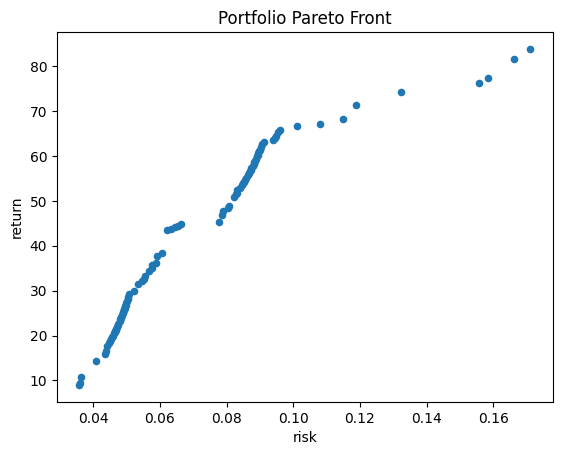

AUC: 7.901674550715494
Epoch number: 6
gen	nevals	auc
0  	100   	0  
1  	100   	25.9677
2  	100   	26.6408
3  	100   	20.6272
4  	100   	14.3876
5  	100   	22.2912
6  	100   	22.1927
7  	100   	22.3181
8  	100   	22.915 
9  	100   	23.4301
10 	100   	23.68  
11 	100   	23.6695
12 	100   	23.5337
13 	100   	17.3154
14 	100   	17.4607
15 	100   	17.4712
16 	100   	17.4783
17 	100   	17.5405
18 	100   	17.5241
19 	100   	17.6563
20 	100   	18.5435
21 	100   	18.5299
22 	100   	18.5514
23 	100   	18.6739
24 	100   	18.7761
25 	100   	18.8715
26 	100   	16.123 
27 	100   	16.1333
28 	100   	16.1352
29 	100   	16.1052
30 	100   	16.0954
31 	100   	16.2441
32 	100   	16.1624
33 	100   	16.2098
34 	100   	16.2097
35 	100   	16.2215
36 	100   	16.2674
37 	100   	16.2662
38 	100   	16.2688
39 	100   	16.2084
40 	100   	16.2087
41 	100   	16.5451
42 	100   	16.5488
43 	100   	16.5477
44 	100   	16.5522
45 	100   	16.5303
46 	100   	16.4588
47 	100   	16.5108
48 	100   	16.529 
49 	100   	16.5029


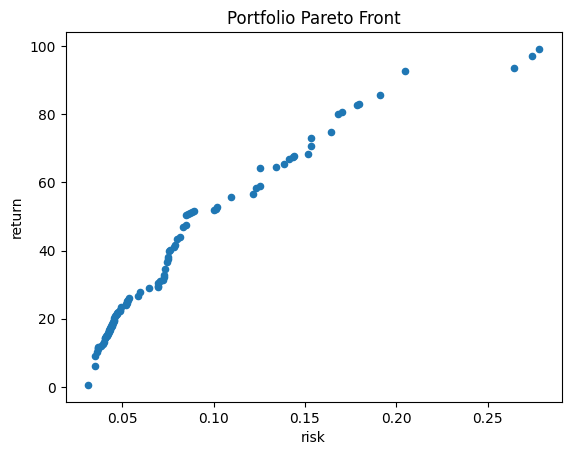

AUC: 16.545002993860702
Epoch number: 7
gen	nevals	auc
0  	100   	0  
1  	100   	3.87832
2  	100   	3.8934 
3  	100   	3.18655
4  	100   	3.33273
5  	100   	2.92895
6  	100   	3.3616 
7  	100   	3.42595
8  	100   	3.36128
9  	100   	4.27219
10 	100   	4.41598
11 	100   	4.34381
12 	100   	4.40233
13 	100   	4.39625
14 	100   	4.36419
15 	100   	4.36279
16 	100   	4.36734
17 	100   	4.37118
18 	100   	4.37026
19 	100   	4.36946
20 	100   	4.37975
21 	100   	4.38113
22 	100   	4.38178
23 	100   	4.38775
24 	100   	4.3938 
25 	100   	4.39654
26 	100   	4.39467
27 	100   	4.40169
28 	100   	4.4023 
29 	100   	4.40665
30 	100   	4.40661
31 	100   	4.40879
32 	100   	4.40997
33 	100   	4.41214
34 	100   	4.41555
35 	100   	4.42178
36 	100   	4.42179
37 	100   	2.57769
38 	100   	2.57764
39 	100   	2.5796 
40 	100   	2.58009
41 	100   	2.5867 
42 	100   	2.84672
43 	100   	2.85135
44 	100   	2.85144
45 	100   	2.86058
46 	100   	2.87788
47 	100   	2.9073 
48 	100   	2.89006
49 	100   	2.89507

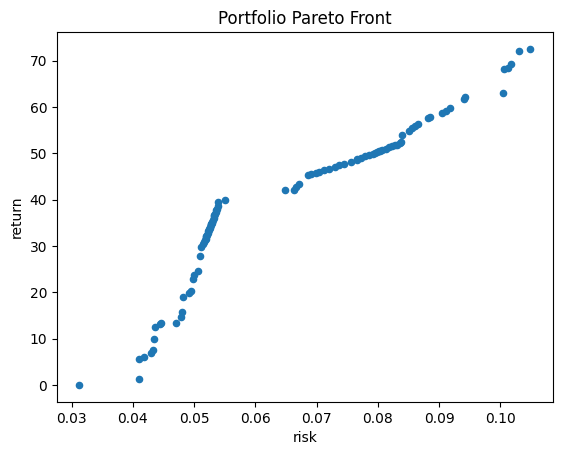

AUC: 2.9001473633437933
Epoch number: 8
gen	nevals	auc
0  	100   	0  
1  	100   	17.4053
2  	100   	25.6632
3  	100   	25.6621
4  	100   	29.909 
5  	100   	32.8395
6  	100   	35.1162
7  	100   	34.7938
8  	100   	23.4644
9  	100   	23.5806
10 	100   	25.9711
11 	100   	27.4283
12 	100   	27.6749
13 	100   	28.4039
14 	100   	28.8878
15 	100   	28.863 
16 	100   	28.9757
17 	100   	29.0285
18 	100   	25.9602
19 	100   	26.3546
20 	100   	26.6897
21 	100   	26.7503
22 	100   	26.9124
23 	100   	27.092 
24 	100   	27.1693
25 	100   	27.22  
26 	100   	27.1721
27 	100   	27.0446
28 	100   	27.1843
29 	100   	27.351 
30 	100   	27.3755
31 	100   	27.5321
32 	100   	27.5283
33 	100   	27.5875
34 	100   	27.5765
35 	100   	27.6617
36 	100   	27.7892
37 	100   	27.8115
38 	100   	27.8395
39 	100   	27.8377
40 	100   	27.9161
41 	100   	27.9164
42 	100   	27.9314
43 	100   	27.9281
44 	100   	27.9292
45 	100   	27.9374
46 	100   	27.9518
47 	100   	28.0293
48 	100   	28.034 
49 	100   	28.099 

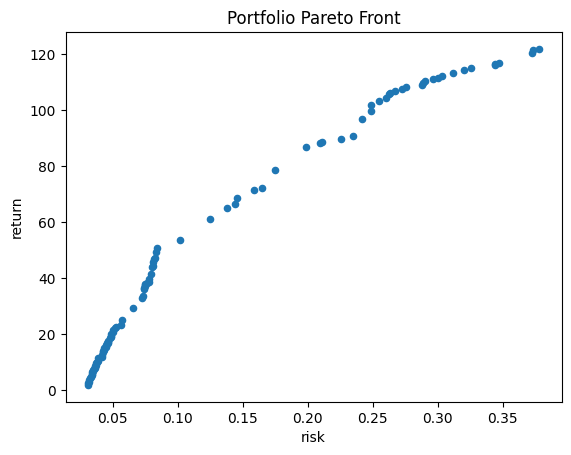

AUC: 28.095390918999612
Epoch number: 9
gen	nevals	auc
0  	100   	0  
1  	100   	1.66372
2  	100   	23.8471
3  	100   	24.1125
4  	100   	25.3792
5  	100   	25.5541
6  	100   	25.6222
7  	100   	2.60013
8  	100   	8.71717
9  	100   	8.55766
10 	100   	8.93385
11 	100   	8.97071
12 	100   	8.96885
13 	100   	9.17401
14 	100   	9.10748
15 	100   	9.08418
16 	100   	9.08257
17 	100   	9.08223
18 	100   	9.15806
19 	100   	9.15661
20 	100   	9.17486
21 	100   	9.17588
22 	100   	9.176  
23 	100   	9.16882
24 	100   	9.16866
25 	100   	9.16796
26 	100   	9.03516
27 	100   	8.99812
28 	100   	8.99816
29 	100   	9.00234
30 	100   	9.00206
31 	100   	8.99524
32 	100   	8.99581
33 	100   	8.99569
34 	100   	8.99632
35 	100   	8.99611
36 	100   	8.99635
37 	100   	8.99601
38 	100   	9.0196 
39 	100   	9.07509
40 	100   	9.08363
41 	100   	9.07841
42 	100   	9.07818
43 	100   	9.0777 
44 	100   	9.08071
45 	100   	9.07936
46 	100   	9.0794 
47 	100   	9.08179
48 	100   	9.10792
49 	100   	9.10831

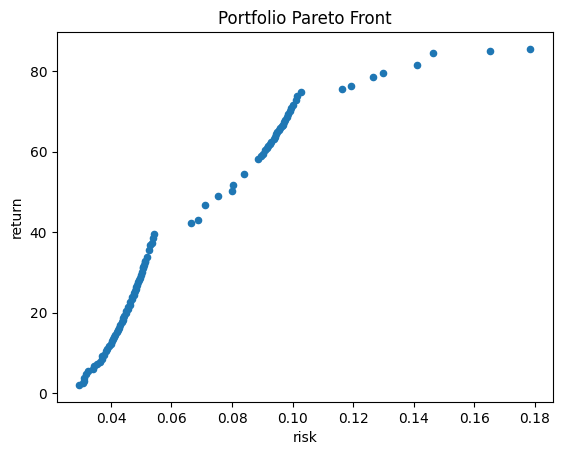

AUC: 9.106562069036999
Epoch number: 10
gen	nevals	auc
0  	100   	0  
1  	100   	21.6939
2  	100   	19.567 
3  	100   	19.7014
4  	100   	19.7333
5  	100   	15.8701
6  	100   	16.3768
7  	100   	7.15602
8  	100   	7.21389
9  	100   	7.25519
10 	100   	7.49891
11 	100   	7.55059
12 	100   	7.61896
13 	100   	7.66078
14 	100   	7.80045
15 	100   	7.80742
16 	100   	7.84091
17 	100   	7.8454 
18 	100   	7.86582
19 	100   	7.87506
20 	100   	7.89445
21 	100   	7.90062
22 	100   	7.89507
23 	100   	7.89317
24 	100   	7.89301
25 	100   	7.89483
26 	100   	7.88924
27 	100   	7.88572
28 	100   	7.8893 
29 	100   	7.88788
30 	100   	7.88808
31 	100   	7.87691
32 	100   	7.88139
33 	100   	7.88462
34 	100   	7.88693
35 	100   	7.89115
36 	100   	7.89139
37 	100   	7.89355
38 	100   	7.8931 
39 	100   	7.89872
40 	100   	7.90899
41 	100   	7.90645
42 	100   	7.9104 
43 	100   	7.91217
44 	100   	7.93564
45 	100   	7.93544
46 	100   	7.94054
47 	100   	7.94712
48 	100   	7.95664
49 	100   	7.95997

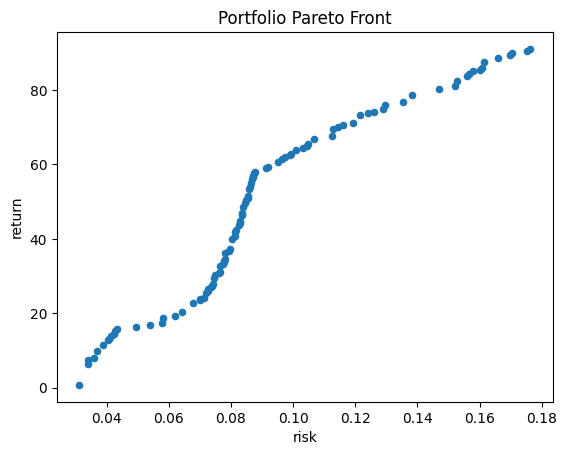

AUC: 7.95918216908406


In [46]:
file_name = 'results_storage/selSPEA2_cxUniform_adaptive_mutUniformInt.pickle'
file_name_csv = 'results_storage/logs_csv/selSPEA2_cxUniform_adaptive_mutUniformInt.csv'

portfolios_epochs_df = pd.DataFrame(columns=['epoch', 'allocation', 'risk', 'return'])
logs_epochs_df = pd.DataFrame(columns=['epoch', 'gen', 'auc'])

print(f'''Initialising optimisation for {epochs} epochs with design:

    -   Selection: {selection_method}
    -   Crossover: {crossover_method}
    -   Mutation: {mutation_method}

      ''')

# Optimisation
for epoch in range(epochs):
    print(f'Epoch number: {epoch+1}')
    pareto_front = tools.ParetoFront()
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    population = toolbox.population(n=population_size)
    start_time = time.time()
    population, log = eaMuPlusLambda_with_auc(population, toolbox, mu=population_size,
                                              lambda_=population_size, cxpb=CXPB,
                                              mutpb=MTPB, ngen=NGENS, stats=stats,
                                              halloffame=pareto_front, verbose=True)
    end_time = time.time()
    execution_time = end_time-start_time

    # Recording results
    pareto_front_final = tools.sortNondominated(population, len(population), first_front_only=True)[0]
    # pareto_front_final = sorted(pareto_front_final, key=lambda x: x.fitness.values[1], reverse=True)[5:] # when budget constraint somehow slips out.

    portfolios_dict = {}
    i=0

    for individual in pareto_front_final:
        i+=1
        individual_variance = individual.fitness.values[0]
        individual_return = individual.fitness.values[1]
        individual = np.array(individual, dtype=int)
        portfolios_dict[i] = [individual, individual_variance, individual_return]

        individual_arr = np.array(individual.tolist())
        individual_cost = np.dot(individual_arr[individual_arr.nonzero()], current_prices[individual_arr.nonzero()])
        if individual_cost > budget:
            print(f'WARNING: budget exceeded. Epoch:{epoch}')

    portfolios_df = pd.DataFrame.from_dict(portfolios_dict, orient='index')
    portfolios_df = portfolios_df.rename(columns={0:'allocation', 1:'risk', 2:'return'})

    portfolios_df.plot(x='risk', y='return', kind='scatter')
    plt.title('Portfolio Pareto Front')
    plt.show()

    log_df = pd.DataFrame(log)
    log_df = log_df.drop(columns=['nevals'])
    log_df['epoch'] = epoch + 1
    log_df[['epoch', 'gen', 'auc']]

    # Final AUC
    area_under_pareto = log_df.iloc[-1]['auc']
    print(f'AUC: {area_under_pareto}')

    #CSV logging
    highest_variance_return = portfolios_df.sort_values(by='return', ascending=False).iloc[0][['risk','return']].values
    lowest_variance_return = portfolios_df.sort_values(by='return', ascending=True).iloc[0][['risk','return']].values
    params = {
        'number_of_stocks': num_assets,
        'population_size': population_size,
        'mutation_rate': MTPB,
        'crossover_rate': CXPB,
        'number_of_generations' : NGENS,
        'mutation_method': mutation_method,
        'crossover_method': crossover_method,
            'selection_method': selection_method
    }

    results = {
        'area_under_pareto_curve': area_under_pareto,
        'computation_time_seconds': execution_time,
        'highest_risk_return': highest_variance_return,
        'lowest_risk_return': lowest_variance_return,
        'raw_log':log
    }

    log_results_to_csv(params, results, file_name_csv)

    #df logging
    portfolios_epochs_df = pd.concat([portfolios_epochs_df, portfolios_df])
    logs_epochs_df = pd.concat([logs_epochs_df, log_df])

with open(file_name, 'wb') as file:
    pickle.dump([portfolios_epochs_df, logs_epochs_df], file)

For loop with 10 iterations for each combination of algorithm design choice. In each iteration, run the optimisation and save the (epoch, gen, auc) from the log in a common df. At the end of the 10 generations, have a signel df with columns [epoch, gen, auc]. This will be used to draw one plot with the 10 iterations stacked on top of each other, with gradient blue from dark to light for best to worse iteration of optimisation. For each combination of algorithm design choice, a new df will be created. Hence, at the end of the 10 iterations, if happy with the resulting plot, save in a pickle file the df.